In [1]:
# =========================================================
# Minimal ConvNeXt + FinerCAM Script (Beemachine)
# =========================================================

import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
MODEL_NAME = r"deit_base_distilled_patch16_224.fb_in1k"
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/1_classification/Beemachine/deit_base_distilled_patch16_224.fb_in1k_timm_new_dataset_logs/checkpoints/best_model.pth"
IMAGE_SIZE = 224
DEVICE = "cuda:0"

# -----------------------------
# Load CSV
# -----------------------------
test_df = pd.read_csv(f"{DATA_DIR}/test_labels.csv")

le = LabelEncoder()
train_df = pd.read_csv(f"{DATA_DIR}/train_aug_labels.csv")
le.fit(train_df["species"])
test_df["label"] = le.transform(test_df["species"])
num_classes = len(le.classes_)

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4925, 0.4475, 0.3490), # Custom normalization values for beemachine_small_2025_v3 (segmentation) dataset
        std=(0.2392, 0.2265, 0.2213)
    )
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], # Imagenet Normalization values
        #              std=[0.229, 0.224, 0.225])
])

# -----------------------------
# Load Model
# -----------------------------
device = torch.device(DEVICE)
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=num_classes
)
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

VisionTransformerDistilled(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inpl

In [3]:
def plot_cam(model, img_path, label, cam_method, ax):
    image_pil = Image.open(img_path).convert("RGB")
    input_tensor = transform(image_pil).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label)]

    # -----------------------------
    # Forward pass (optional check)
    # -----------------------------
    with torch.no_grad():
        output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    print(f"True label: {label}")
    print(f"Predicted: {pred}")

    # -----------------------------
    # Generate CAM
    # -----------------------------
    grayscale_cam = cam_method(
        input_tensor=input_tensor,
        targets=targets
    )
    grayscale_cam = grayscale_cam[0]  # remove batch dim

    # -----------------------------
    # Overlay (Correct Version)
    # -----------------------------
    rgb_img = np.array(image_pil).astype(np.float32) / 255.0

    # Resize CAM to original image size
    grayscale_cam = cv2.resize(
        grayscale_cam,
        (rgb_img.shape[1], rgb_img.shape[0])
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    ax.imshow(visualization)
    ax.axis("off")  

In [4]:
# -----------------------------
# 🔥 IMPORTANT: reshape for DeiT
# -----------------------------
def reshape_transform(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]

    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)

    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# -----------------------------
# FinerCAM Setup
# Target layer: (last block norm)
# -----------------------------
target_layers = [model.blocks[-1].norm1]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

True label: 121
Predicted: 121


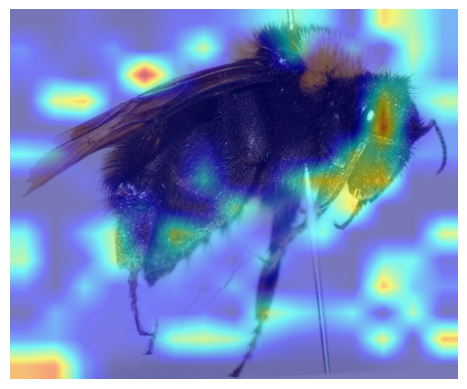

In [5]:
# -----------------------------
# Select one test image
# -----------------------------
image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 40
Predicted: 40
True label: 59
Predicted: 59
True label: 106
Predicted: 34
True label: 70
Predicted: 70
True label: 138
Predicted: 138
True label: 42
Predicted: 42
True label: 127
Predicted: 127


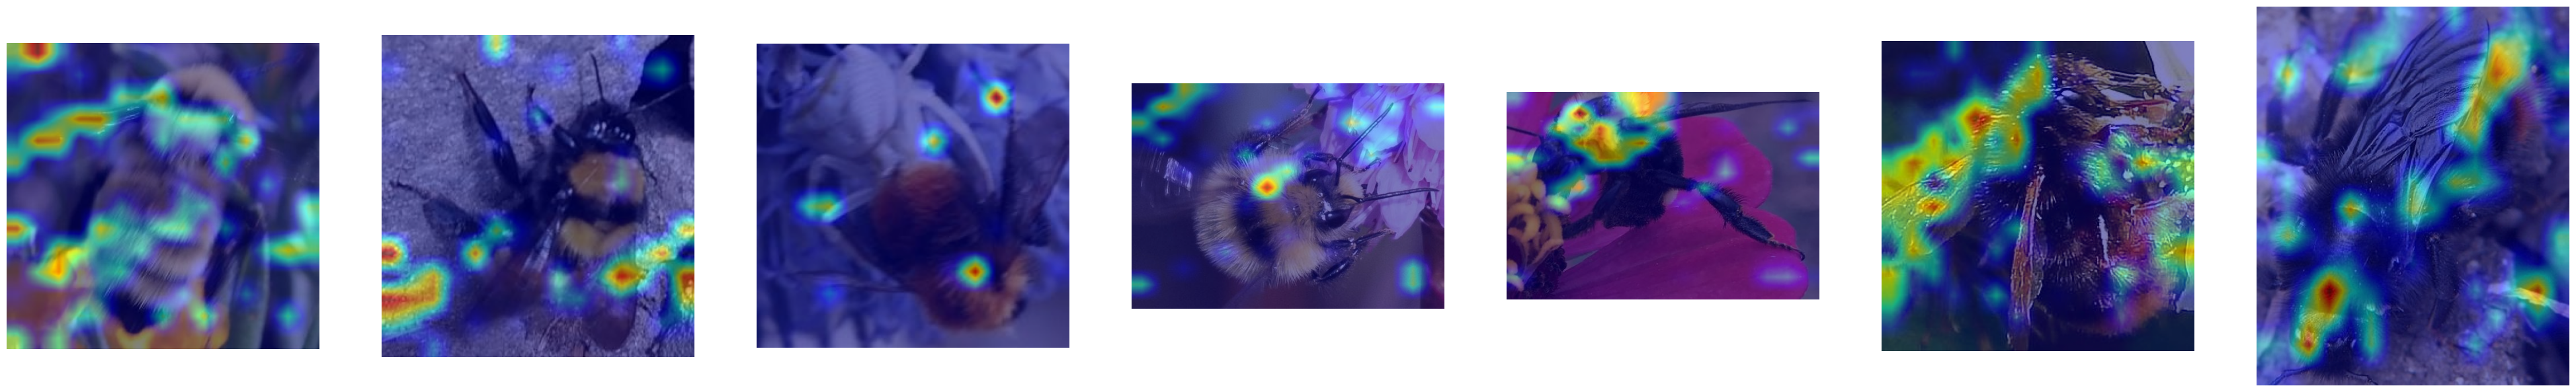

In [6]:
image_ids = [5,4,88,555,443,123,321]
num_images = len(image_ids)
fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=(50, 50*num_images))
for i,img_id in enumerate(image_ids):
    row = test_df.iloc[img_id]
    img_path = f"{DATA_DIR}/test/images/{row['image']}"
    label = int(row["label"])
    plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes[i])
plt.show()

True label: 121
Predicted: 121


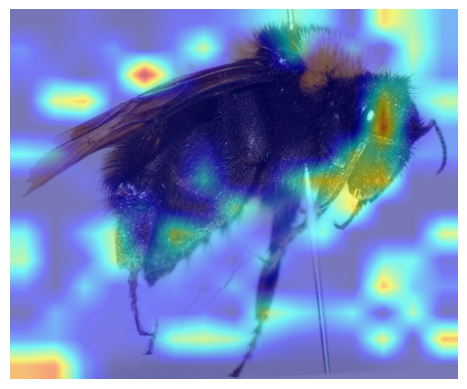

In [7]:
image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


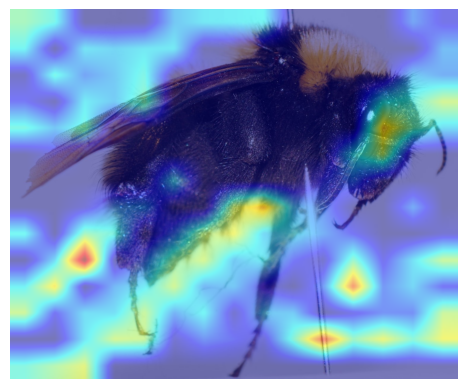

In [8]:
# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -3, -4, and -6)
# -----------------------------
target_layers = [model.blocks[-3].norm1]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


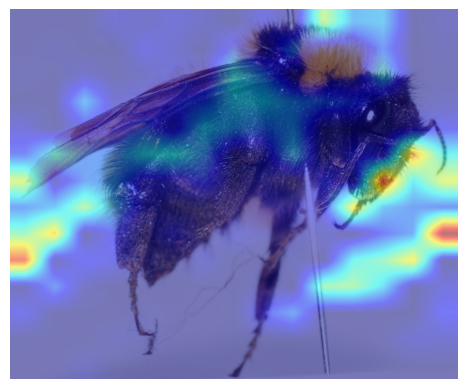

In [9]:
# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -3, -4, and -6)
# -----------------------------
target_layers = [model.blocks[-4].norm1]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


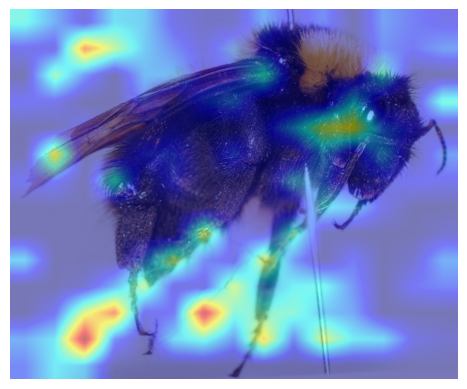

In [10]:
# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-6].norm1]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


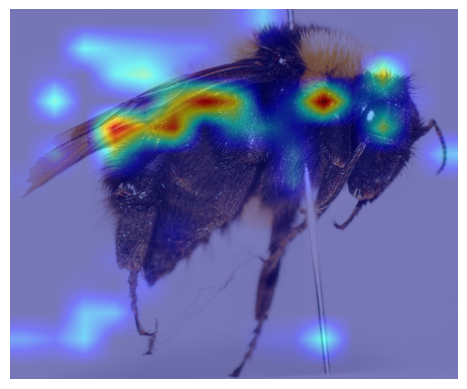

In [11]:
# Also checking norm2

# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-6].norm2]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


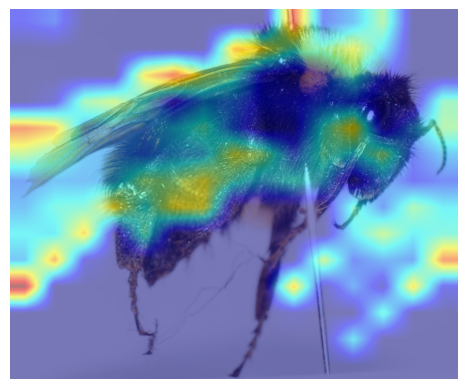

In [12]:
# Also checking norm2

# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-4].norm2]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


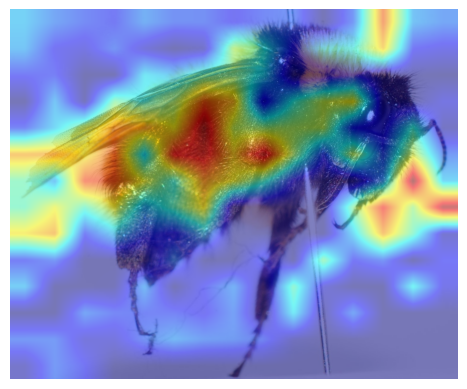

In [13]:
# Also checking norm2

# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-3].norm2]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


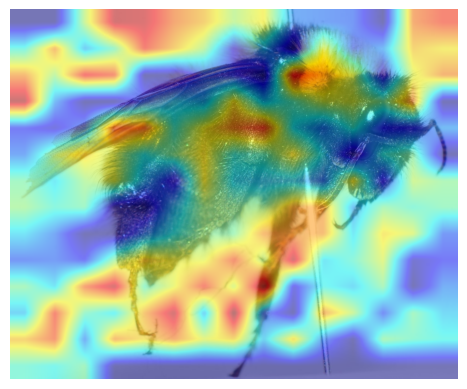

In [14]:
# Also checking norm2

# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-1].norm2]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


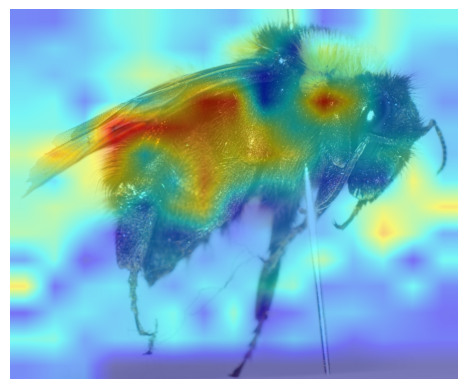

In [15]:
# Now checking if we can average over multiple blocks

# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-i].norm2 for i in [1, 3, 4, 6]]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

True label: 121
Predicted: 121


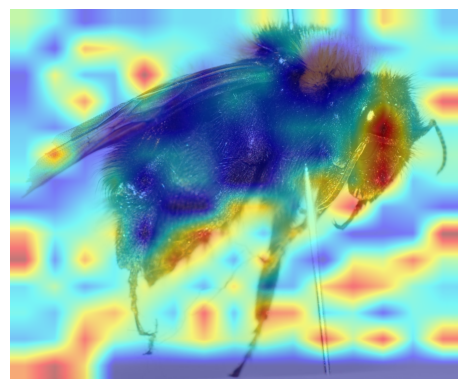

In [16]:
# Now checking if we can average over multiple blocks

# Now looking at other layers
# -----------------------------
# FinerCAM Setup
# Target layer: (last block norms: checking -1, -6 and -3)
# -----------------------------
target_layers = [model.blocks[-i].norm1 for i in [1, 3, 4, 6]]
cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

image_no = 0
row = test_df.iloc[image_no]
img_path = f"{DATA_DIR}/test/images/{row['image']}"
label = int(row["label"])

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model, img_path=img_path, label=label, cam_method=cam, ax=axes)

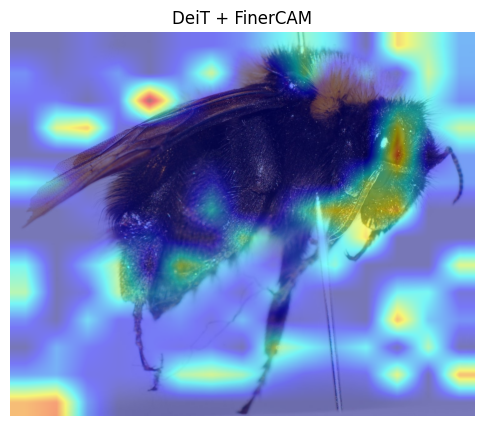

In [17]:
# =========================================================
# Minimal DeiT + FinerCAM Script (timm)
# =========================================================

import torch
import timm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------------
# CONFIG
# -----------------------------
MODEL_NAME = "deit_base_distilled_patch16_224.fb_in1k"
IMAGE_SIZE = 224
DEVICE = "cuda:0"

# -----------------------------
# Load model
# -----------------------------
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=num_classes
)

model.to(DEVICE)
model.load_state_dict(state_dict)
model.eval()

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4925, 0.4475, 0.3490),
        std=(0.2392, 0.2265, 0.2213)
    )
])

# -----------------------------
# Load image
# -----------------------------
image_pil = Image.open(img_path).convert("RGB")
input_tensor = transform(image_pil).unsqueeze(0).to(DEVICE)

def reshape_transform(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]

    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)

    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# -----------------------------
# Target layer (last block norm)
# -----------------------------
target_layers = [model.blocks[-1].norm1]

cam = FinerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

targets = [ClassifierOutputTarget(label)]

# -----------------------------
# Generate CAM
# -----------------------------
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

# -----------------------------
# Resize to original image
# -----------------------------
rgb_img = np.array(image_pil).astype(np.float32) / 255.0

grayscale_cam = cv2.resize(
    grayscale_cam,
    (rgb_img.shape[1], rgb_img.shape[0])
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title("DeiT + FinerCAM")
plt.axis("off")
plt.show()